# Hyperion Chaotic Rotation and Lyapunov Analysis

Coupled orbital and rotational dynamics of a dumbbell model of Hyperion, with angular separation and Lyapunov fits.

Computational physics coursework by Udayan Sharma. Original code comments and saved outputs are retained. See the repository README for execution notes.


Hyperion CM position x_0 [HU]: 1
                     y_0 [HU]: 0
    CM velocity vx_0 [HU/Hyr]: 0
                vy_0 [HU/Hyr]: 7.163933479
Axis angle [rad]:0
Axis angular velocity [rad/Hyr]:1
t_end [Hyr]: 10
dt [Hyr]: 0.0001


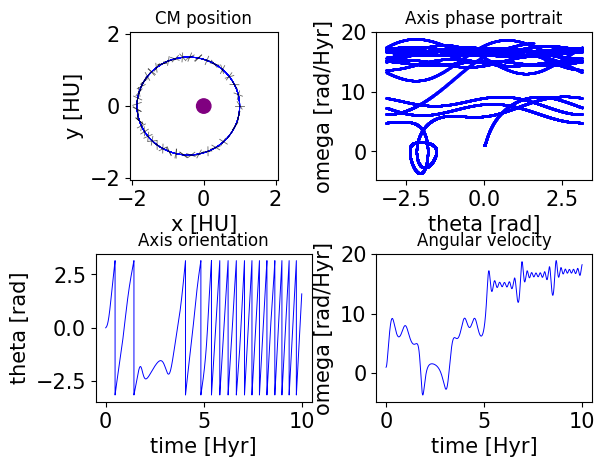

In [ ]:
# Lab 6 - Task 1

from math import sqrt, sin, cos;
from math import pi as PI;
import numpy as np;
import matplotlib;
import matplotlib.pyplot as plt;


def computeMotion(initconds, dt, nsteps):
    (x0, y0, vx0, vy0, th0, om0) = initconds;

    if dt <= 0:   raise ValueError("dt must be positive.");
    if nsteps < 1:   raise ValueError("nsteps must be >= 1 (check t_end and dt).");

    # If you hit this it means your orbit collided with Saturn
    r_min = 1e-8;
    r0 = sqrt(x0*x0 + y0*y0);
    if r0 < r_min:
        raise ValueError("Initial radius r0 is ~0 (x0 = y0 = 0). " "Choose a nonzero starting position");

    # allocate storage
    x = np.zeros(nsteps + 1);
    y = np.zeros(nsteps + 1);
    theta = np.zeros(nsteps + 1);
    omega = np.zeros(nsteps + 1);

    # load initconds
    x[0], y[0] = x0, y0;
    theta[0], omega[0] = th0, om0;
    vx, vy = vx0, vy0;

    GM = 4.0 * PI**2;

    for i in range(nsteps):
        # radius at current step
        r = sqrt(x[i]*x[i] + y[i]*y[i]);
        if r < r_min:
            raise RuntimeError(f"Collision : r ≈ 0 at step {i}, t = {i*dt:.6g} Hyr. " "Check initial conditions or dt.");

        # update CM velocity (Euler-Cromer)
        inv_r3 = 1.0 / (r*r*r);
        vx = vx - GM * x[i] * dt * inv_r3;
        vy = vy - GM * y[i] * dt * inv_r3;

        # then CM position
        x[i + 1] = x[i] + dt * vx;
        y[i + 1] = y[i] + dt * vy;

        # rotational update (uses same r, consistent with force eval at step i)
        angularTerm  = x[i] * sin(theta[i]) - y[i] * cos(theta[i]);
        angularTerm *= x[i] * cos(theta[i]) + y[i] * sin(theta[i]);

        inv_r5 = 1.0 / (r*r*r*r*r);
        omega[i + 1] = omega[i] - dt * 3.0 * GM * inv_r5 * angularTerm;
        theta[i + 1] = theta[i] + dt * omega[i + 1];

        # map angle to [-pi, pi)
        if theta[i + 1] >= PI:   theta[i + 1] -= 2.0 * PI;
        if theta[i + 1] < -PI:   theta[i + 1] += 2.0 * PI;

    return x, y, theta, omega;

# initial conditions
x0  = float( input('Hyperion CM position x_0 [HU]: ') );
y0  = float( input('                     y_0 [HU]: ') );
vx0 = float( input('    CM velocity vx_0 [HU/Hyr]: ') );
vy0 = float( input('                vy_0 [HU/Hyr]: ') );
th0 = float( input('Axis angle [rad]:' ) );
om0 = float( input('Axis angular velocity [rad/Hyr]:' ) );

# computational parameters
t_end  = float( input('t_end [Hyr]: ') );
dt     = float( input('dt [Hyr]: ') );
nsteps = int(t_end / dt + 0.5);

initconds = (x0, y0, vx0, vy0, th0, om0);
xvals, yvals, thvals, omvals = computeMotion(initconds, dt, nsteps);
timevals = [ dt * i  for i in range(nsteps + 1) ];

fontsize = 15;
linewidth = 0.7;
pointarea = 0.5;

# make 2x2 plot
fig, axArray = plt.subplots(2, 2);
((ax0, ax1), (ax2, ax3)) = axArray;

# TOP LEFT: x-y
ax0.tick_params(labelsize = fontsize);
#ax0.legend(fontsize = fontsize)
ax0.set_xlabel("x [HU]", fontsize = fontsize);
ax0.set_ylabel("y [HU]", fontsize = fontsize);
ax0.set_xlim((-1.5, 1.5));
ax0.set_ylim((-1.5, 1.5));
ax0.set_title("CM position");

# depict Saturn at origin
ax0.add_artist( plt.Circle((0, 0), 0.2, color = "purple") );

ax0.plot(xvals, yvals, linewidth = linewidth, color = "blue");

# Draw dumbbell axis
L = 0.25;   # axis length in HU
stride = max(1, len(xvals)//80);

for k in range(0, len(xvals), stride):
    cx, cy = xvals[k], yvals[k];
    th = thvals[k];
    dx = 0.5 * L * np.cos(th);
    dy = 0.5 * L * np.sin(th);
    ax0.plot([cx - dx, cx + dx], [cy - dy, cy + dy], color = "black", linewidth = 0.6, alpha = 0.6);

# auto-scale limits so ellipses don't get clipped
rmax = max(np.sqrt(np.array(xvals)**2 + np.array(yvals)**2));
pad = 0.2;
ax0.set_xlim((-rmax - pad, rmax + pad));
ax0.set_ylim((-rmax - pad, rmax + pad));
ax0.set_aspect('equal', adjustable = 'box');

# TOP RIGHT: theta-omega
ax1.tick_params(labelsize = fontsize);
#ax1.legend(fontsize = fontsize)
ax1.set_xlabel("theta [rad]", fontsize = fontsize);
ax1.set_ylabel("omega [rad/Hyr]", fontsize = fontsize);
ax1.set_title("Axis phase portrait");

#ax1.plot(thvals, omvals, linewidth = linewidth, color = "blue")
ax1.scatter(thvals, omvals, s = pointarea, color = "blue", marker = ".");

# BOTTOM LEFT:  theta vs t
ax2.tick_params(labelsize = fontsize);
#ax2.legend(fontsize = fontsize);
ax2.set_xlabel("time [Hyr]", fontsize = fontsize);
ax2.set_ylabel("theta [rad]", fontsize = fontsize);
ax2.set_title("Axis orientation");

ax2.plot(timevals, thvals, linewidth = linewidth, color = "blue");

# BOTTOM RIGHT:  omega vs t
ax3.tick_params(labelsize = fontsize);
#ax3.legend(fontsize = fontsize);
ax3.set_xlabel("time [Hyr]", fontsize = fontsize);
ax3.set_ylabel("omega [rad/Hyr]", fontsize = fontsize);
ax3.set_title("Angular velocity");

ax3.plot(timevals, omvals, linewidth = linewidth, color = "blue");

plt.subplots_adjust(wspace = 0.3, hspace = 0.5);
plt.show();

#EOF


Hyperion CM position x_0 [HU]: 1
                     y_0 [HU]: 0
    CM velocity vx_0 [HU/Hyr]: 0
                vy_0 [HU/Hyr]: 6.658397928
Axis angle theta_0 [rad]: 0
Axis angular velocity omega_0 [rad/Hyr]: 1
Small delta theta_0 [rad] (e.g. 1e-6 to 1e-3): 0.001
Small delta omega_0 [rad/Hyr] (e.g. 0): 0
t_end [Hyr]: 50
dt [Hyr]: 0.0001

Found maxima points:
  Δθ_sep maxima: 9 points
  |Δω|  maxima:  13 points
Fit Δθ_sep maxima? Enter start,end (0-based) or blank to skip: 0,8
Δθ_sep fit: λ = 0.113495 [1/Hyr], R^2 = 0.8029
Fit |Δω| maxima? Enter start,end (0-based) or blank to skip: 0,8
|Δω|  fit: λ = 0.19511 [1/Hyr], R^2 = 0.7059


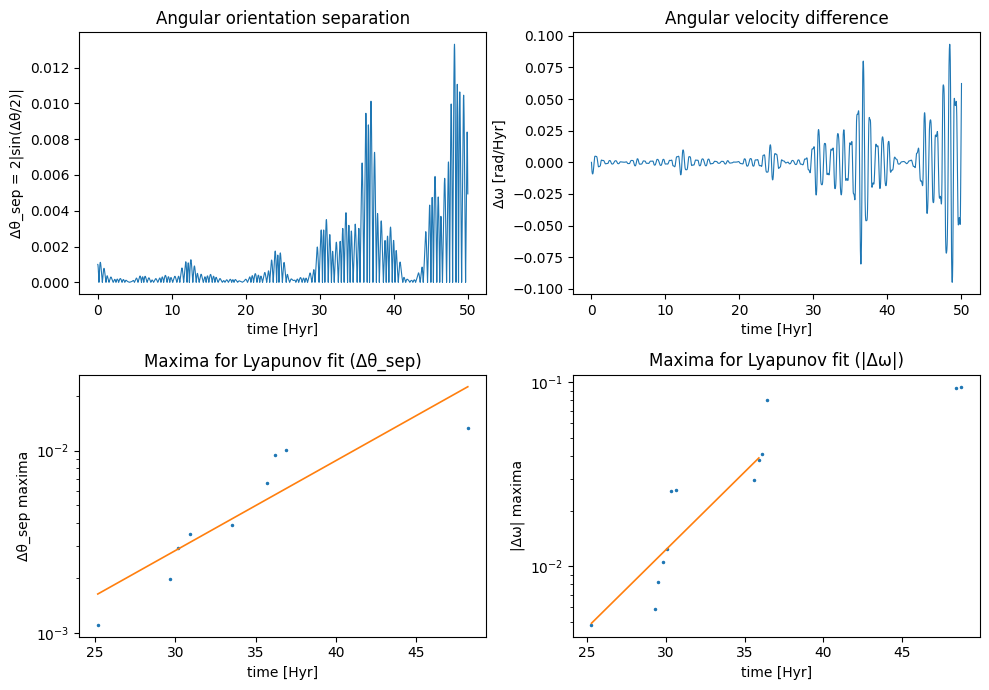

In [ ]:
# Lab 6 — Task 2

from math import sqrt;
from math import pi as PI;
import numpy as np;
import matplotlib.pyplot as plt;


def wrap_pm_pi(angle):
    return (angle + PI) % (2.0 * PI) - PI;

# angular separation -> Range: [0, 2]; Δθ_sep = 2 |sin((θ2-θ1)/2)|; For small differences, Δθ_sep ≈ |θ2-θ1|.
def angle_separation(theta1, theta2):
    return 2.0 * np.abs(np.sin(0.5 * (theta2 - theta1)));

# Return monotone 'upper envelope' by taking running maximum of maxima.
def running_max_envelope(tmax, ymax, tmin = None):
    if len(ymax) == 0:
        return tmax, ymax;
    if tmin is not None:
        mask = tmax >= tmin;
        tmax = tmax[mask];
        ymax = ymax[mask];
        if len(ymax) == 0:
            return tmax, ymax;
    env = np.maximum.accumulate(ymax);
    # keep only points where the envelope increases (remove duplicates)
    keep = np.concatenate(([True], env[1:] > env[:-1]));
    return tmax[keep], env[keep];

# Indices i where arr[i] is a strict local maximum
def local_maxima_indices(arr):
    if len(arr) < 3:
        return np.array([], dtype = int)
    return np.where((arr[1:-1] > arr[:-2]) & (arr[1:-1] > arr[2:]))[0] + 1

# it ln(y) = ln(A) + λ t over maxima indices [start_idx, end_idx]
def fit_lyapunov(t_max, y_max, start_idx, end_idx):
    t_fit = t_max[start_idx:end_idx + 1];
    y_fit = y_max[start_idx:end_idx + 1];

    eps = 1e-300;
    logy = np.log(np.maximum(y_fit, eps));

    lam, lnA = np.polyfit(t_fit, logy, 1);
    logy_pred = lam * t_fit + lnA;

    ss_res = np.sum((logy - logy_pred) ** 2);
    ss_tot = np.sum((logy - np.mean(logy)) ** 2);
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan;
    return lam, lnA, r2;

# split "start,end" into two ints
def parse_range(s, npts, label = ""):
    s = s.strip();
    if not s:
        return None;
    try:
        a_str, b_str = s.split(",");
        a, b = int(a_str.strip()), int(b_str.strip());
    except Exception:
        raise ValueError(f"{label} fit range must be two integers like 0,12 (or blank to skip).");

    if a < 0 or b < 0 or a >= npts or b >= npts or a > b:
        raise ValueError(f"{label} fit range must satisfy 0 <= start <= end <= {npts - 1}.");
    return a, b;


# Dynamics

def compute_orbit(x0, y0, vx0, vy0, dt, nsteps, GM):
    # Euler–Cromer integrator for CM orbit only
    x = np.zeros(nsteps + 1);
    y = np.zeros(nsteps + 1);
    x[0], y[0] = x0, y0;
    vx, vy = vx0, vy0;

    for i in range(nsteps):
        r = sqrt(x[i] ** 2 + y[i] ** 2);
        if r < 1e-12:  raise ZeroDivisionError("Orbit crashed (r≈0). Check ICs or reduce dt.");

        inv_r3 = 1.0 / (r * r * r);
        vx = vx - GM * x[i] * dt * inv_r3;
        vy = vy - GM * y[i] * dt * inv_r3;
        x[i + 1] = x[i] + dt * vx;
        y[i + 1] = y[i] + dt * vy;

    return x, y;

# Evolve theta and omega driven by orbit
def compute_axis_on_orbit(x, y, th0, om0, dt, GM):
    nsteps = len(x) - 1;
    theta = np.zeros(nsteps + 1);
    omega = np.zeros(nsteps + 1);
    theta[0], omega[0] = th0, om0;

    for i in range(nsteps):
        r = sqrt(x[i] ** 2 + y[i] ** 2);
        if r < 1e-12:  raise ZeroDivisionError("Orbit crashed (r≈0). Check ICs or reduce dt.");

        angularTerm = x[i] * np.sin(theta[i]) - y[i] * np.cos(theta[i]);
        angularTerm *= x[i] * np.cos(theta[i]) + y[i] * np.sin(theta[i]);

        inv_r5 = 1.0 / (r * r * r * r * r);
        omega[i + 1] = omega[i] - dt * 3.0 * GM * inv_r5 * angularTerm;
        theta[i + 1] = wrap_pm_pi(theta[i] + dt * omega[i + 1]);

    return theta, omega;


# Inputs

GM = 4.0 * PI ** 2;

# Orbit ICs
x0 = float(input("Hyperion CM position x_0 [HU]: "));
y0 = float(input("                     y_0 [HU]: "));
vx0 = float(input("    CM velocity vx_0 [HU/Hyr]: "));
vy0 = float(input("                vy_0 [HU/Hyr]: "));
# Axis ICs (base)
th0 = float(input("Axis angle theta_0 [rad]: "));
om0 = float(input("Axis angular velocity omega_0 [rad/Hyr]: "));

# Small perturbations
dth0 = float(input("Small delta theta_0 [rad] (e.g. 1e-6 to 1e-3): "));
dom0 = float(input("Small delta omega_0 [rad/Hyr] (e.g. 0): "));

# Time parameters
t_end = float(input("t_end [Hyr]: "));
dt = float(input("dt [Hyr]: "));
if dt <= 0:  raise ValueError("dt must be positive.")
nsteps = int(t_end / dt + 0.5);
if nsteps < 2:  raise ValueError("t_end/dt too small; increase t_end or decrease dt.");
time = np.arange(nsteps + 1) * dt;


# Compute
# 1) Orbit once
x, y = compute_orbit(x0, y0, vx0, vy0, dt, nsteps, GM);
# 2) Axis twice on the same orbit
theta1, omega1 = compute_axis_on_orbit(x, y, th0, om0, dt, GM);
theta2, omega2 = compute_axis_on_orbit(x, y, th0 + dth0, om0 + dom0, dt, GM);
# 3) Differences
dtheta_sep = angle_separation(theta1, theta2);
domega = omega2 - omega1;
abs_domega = np.abs(domega);
# 4) Maxima (for semilog fit)
im_th = local_maxima_indices(dtheta_sep);
im_om = local_maxima_indices(abs_domega);

tmax_th_raw, ymax_th_raw = time[im_th], dtheta_sep[im_th];
tmax_om_raw, ymax_om_raw = time[im_om], abs_domega[im_om];
# Use envelope after transient - for e = 0.123, tmin ~ 25 Hyr works well
tmax_th, ymax_th = running_max_envelope(tmax_th_raw, ymax_th_raw, tmin = 25.0);
tmax_om, ymax_om = running_max_envelope(tmax_om_raw, ymax_om_raw, tmin = 25.0);

print("\nFound maxima points:");
print(f"  Δθ_sep maxima: {len(ymax_th)} points");
print(f"  |Δω|  maxima:  {len(ymax_om)} points");

# Optional fits (user picks range on maxima arrays)
lam_th = lnA_th = r2_th = None;
lam_om = lnA_om = r2_om = None;
win_th = None;
win_om = None;

if len(ymax_th) >= 2:
    s = input("Fit Δθ_sep maxima? Enter start,end (0-based) or blank to skip: ");
    win_th = parse_range(s, len(ymax_th), label = "Δθ_sep");
    if win_th is not None:
        a, b = win_th;
        lam_th, lnA_th, r2_th = fit_lyapunov(tmax_th, ymax_th, a, b);
        print(f"Δθ_sep fit: λ = {lam_th:.6g} [1/Hyr], R^2 = {r2_th:.4f}");

if len(ymax_om) >= 2:
    s = input("Fit |Δω| maxima? Enter start,end (0-based) or blank to skip: ");
    win_om = parse_range(s, len(ymax_om), label = "|Δω|");
    if win_om is not None:
        a, b = win_om;
        lam_om, lnA_om, r2_om = fit_lyapunov(tmax_om, ymax_om, a, b);
        print(f"|Δω|  fit: λ = {lam_om:.6g} [1/Hyr], R^2 = {r2_om:.4f}");

# Plots
fig, ax = plt.subplots(2, 2, figsize = (10, 7));
(ax0, ax1), (ax2, ax3) = ax;

# Δθ_sep(t)
ax0.plot(time, dtheta_sep, lw = 0.8);
ax0.set_title("Angular orientation separation");
ax0.set_xlabel("time [Hyr]");
ax0.set_ylabel("Δθ_sep = 2|sin(Δθ/2)|");

# Δω(t)
ax1.plot(time, domega, lw = 0.8);
ax1.set_title("Angular velocity difference");
ax1.set_xlabel("time [Hyr]");
ax1.set_ylabel("Δω [rad/Hyr]");

# Semilog maxima (Δθ_sep)
if len(ymax_th) > 0:
    ax2.semilogy(tmax_th, ymax_th, ".", ms = 3);
ax2.set_title("Maxima for Lyapunov fit (Δθ_sep)");
ax2.set_xlabel("time [Hyr]");
ax2.set_ylabel("Δθ_sep maxima");

if lam_th is not None and win_th is not None:
    a, b = win_th;
    tfit = np.linspace(tmax_th[a], tmax_th[b], 200);
    ax2.semilogy(tfit, np.exp(lnA_th + lam_th * tfit), lw = 1.2);

# Semilog maxima (|Δω|)
if len(ymax_om) > 0:
    ax3.semilogy(tmax_om, ymax_om, ".", ms = 3);
ax3.set_title("Maxima for Lyapunov fit (|Δω|)");
ax3.set_xlabel("time [Hyr]");
ax3.set_ylabel("|Δω| maxima");

if lam_om is not None and win_om is not None:
    a, b = win_om;
    tfit = np.linspace(tmax_om[a], tmax_om[b], 200);
    ax3.semilogy(tfit, np.exp(lnA_om + lam_om * tfit), lw = 1.2);

plt.tight_layout();
plt.show();

#EOF
